## Shear-flow tearing by autodiff eigenvalues, against the paper's eigencode

**Rung 1b-ref of `plans/AUTODIFF_PLAN.md`.** Rung 1a (`tearing-eigen.ipynb`) validated the
eigen-harness `taranis/stability.py` -- the exact Jacobian $J=L+N'(x_0)$ of the solver's own
discrete right-hand side, from `apply_L` plus a `jax.jvp` of `construct_rhs` -- against exact
tearing theory for a static sheet. Here the equilibrium carries a **field-aligned shear flow**,
$\Phi_0=\alpha\Psi_0$ (so $\mathbf u_0=\alpha\,\mathbf b_{\perp0}$), the setup of Mallet, Eriksson,
Swisdak & Juno, JPP **91**, E146 (2025) ("the paper", §7), and the growth rates are compared with
**Alfred's Julia eigencode**, the code behind the paper's figures: 2nd-order finite differences
on a geometrically stretched grid with a Robin outer boundary, vendored unchanged as
`tests/reference/shear_tearing_eigen.jl`. Its results, with its own convergence study, are
`tests/data/shear_tearing_reference.npz` (the generator's header documents every key). No
linearized equation is written on the taranis side; the two codes share nothing but the
physics.

**Setup** (everything): `dims=2`, $\nu=0$ (`diss=(0, η)`), `hyper=1`, $a=v_{Ay}=1$, $S=1/\eta$,
$L_y=2\pi/k$, `ny=8`, the $k_y=k$ block (`iky=1`), fp64. Two profiles, as in the reference:

* **whichf = 2:** $\Psi_0=\mathrm{sech}^2x$, $f=B_y=\Psi_0'=-2\tanh x\,\mathrm{sech}^2x$ -- rung 1a's
  box $L_x=\max(15/k,20)$ with the two nearest periodic images; 90 points
  $S\in\{10^3,10^4,10^5\}\times ka\in\{0.1,0.2,0.3,0.5,0.7,1\}\times\alpha\in\{0,0.3,0.6,0.8,0.95\}$.
* **whichf = 1:** $f=\tanh x$, which is not periodic (§4); 36 points,
  $\alpha\in\{0,0.8\}$, of which the 6 at $ka=1$ ($\Delta'=0$) are stable.

**The linearized block is literally the Julia code's.** With taranis's brackets
($\mathbf u=\hat z\times\nabla\phi$, $\mathbf b_\perp=\hat z\times\nabla\psi$,
$\partial_t\psi=-\{\phi,\psi\}+\eta\nabla^2\psi$,
$\partial_t\nabla^2\phi=-\{\phi,\nabla^2\phi\}+\{\psi,\nabla^2\psi\}$), perturbations
$\propto e^{\gamma t+iky}$ about $(\alpha\Psi_0,\Psi_0)$ obey
$$\gamma\psi=\eta(\partial_x^2-k^2)\psi-i\alpha kf\psi+ikf\phi,\qquad
\gamma(\partial_x^2-k^2)\phi=ik[f(\partial_x^2-k^2)\psi-f''\psi]-i\alpha k[f(\partial_x^2-k^2)\phi-f''\phi],$$
term for term the pencil assembled in `operators` of the `.jl` file (`ar` $=\alpha$, `K` $=ka$),
same sign of $\alpha$. The spectrum is anyway **even in $\alpha$**: $y\to-y$, $\phi\to-\phi$ is a
symmetry of RMHD that maps $\alpha\to-\alpha$ (checked in §1; `tests/test_tearing_shear.py` gates it,
and gates the sign of $\alpha$ through one stored Julia eigenfunction).

**Solver** (rung 1a's machinery, imported from `tearing_eigen_run.py`, which gained an `alpha`
keyword and the tanh-pair profile): shift-invert on the matrix-free `ky_block_operator`, GMRES
preconditioned by an exact sparse LU of the block's band; $n_x$ doubled until successive
eigenvalues agree to $10^{-7}$; every pair passes the harness's residual gate against the exact
operator. The first $S$ of each $(ka,\alpha)$ is seeded by a dense spectrum, later $S$ by
continuation. Dense spectra (`eig_dense`, the whole block) certify the fastest mode (§5).

**How to read the reference's error bar.** `gamma` is the Julia base-grid value and `gamma_err`
its relative error bar $=\max$(conv_err, richardson_err); `gamma_richardson` extrapolates the
base grid under joint $(dx_{min},\epsilon)$ halving at the observed 2nd order. For **104 of the
120 unstable rows the Richardson term IS the bar**, i.e. `gamma_err` $=|$`gamma`$-$`gamma_richardson`$|/|$`gamma`$|$
exactly -- so a code that is exact sits exactly one bar from `gamma` (0.98-1.02 bars is "agreement"),
and the discriminating comparison is against `gamma_richardson`, with `gamma_err` as a
(generous) bar. Both are printed. Acceptance (plan): agreement within the larger of the two codes'
measured errors.

**Data.** `tearing_shear_run.py` (resumable `make_data()`, per-solve cache under
`examples/data/tearing-shear/`, gitignored). The first execution computes (cost cell at the
end); every later one only reads.

In [1]:
# fp64 must be selected before taranis/jax import (TARANIS_PRECISION is read at import)
import os
os.environ["TARANIS_PRECISION"] = "64"
import time
import numpy as np
import matplotlib.pyplot as plt
import tearing_eigen_run as T
import tearing_shear_run as R

t0 = time.time()
while not R.make_data(wall_budget=3600.0, log=lambda *a: None):
    pass          # resumable: each call does <= 1 h of missing solves; cached ones are free
print(f"data ready ({time.time() - t0:.0f} s this call)")
REF = R.load_ref()
MAIN = R.main_results()           # {(whichf, ka, alpha): {S: ladder}}
DENSE = R.dense_results()         # {(whichf, S, ka, alpha): dense record}

field variables are using 64bit precision.
data ready (1 s this call)


### 1. Conventions: $\alpha\to-\alpha$, and the eigenfunctions against the Julia code's

In [2]:
# (a) the spectrum is even in alpha; (b) Julia's sign of alpha is taranis's (it could not
# matter for eigenvalues, but the eigenfunctions are compared below): a small dense block
S, ka, Lx, nx = 1e3, 1.0, 20.0, 512
top = {al: T.dense_spectrum("sech2", S, ka, nx, Lx, alpha=al, nkeep=6) for al in (0.8, -0.8)}
lp, lm = top[0.8]["values"][0], top[-0.8]["values"][0]
print(f"fastest eigenvalue, alpha = +0.8: {lp:.12f};  alpha = -0.8: {lm:.12f};  |diff| = {abs(lp - lm):.1e}")
# the eigenfunction of the Julia code (stored for (whichf, S, ka, alpha) = (2, 1e4, 0.3, 0.8))
pid = [p for p in REF["eigfn_pids"]]
print("Julia eigenfunctions stored for rows", pid)

fastest eigenvalue, alpha = +0.8: 0.043435253263+0.000000000000j;  alpha = -0.8: 0.043435253263-0.000000000000j;  |diff| = 2.4e-14
Julia eigenfunctions stored for rows [np.int64(34), np.int64(40), np.int64(43), np.int64(87), np.int64(109)]


  row  (whichf, S, ka, alpha)          max |taranis - Julia| over |x| < 1.4 (psi, phi), normalized units
   34  (2, 1e+04, 0.1, 0.95)   1.2e-02, 1.1e-02
   40  (2, 1e+04, 0.3, 0.0)   8.3e-04, 4.8e-04
   43  (2, 1e+04, 0.3, 0.8)   1.3e-03, 1.0e-03
   87  (2, 1e+05, 1.0, 0.6)   6.5e-04, 7.6e-04
  109  (1, 1e+04, 0.5, 0.8)   9.2e-05, 7.4e-05


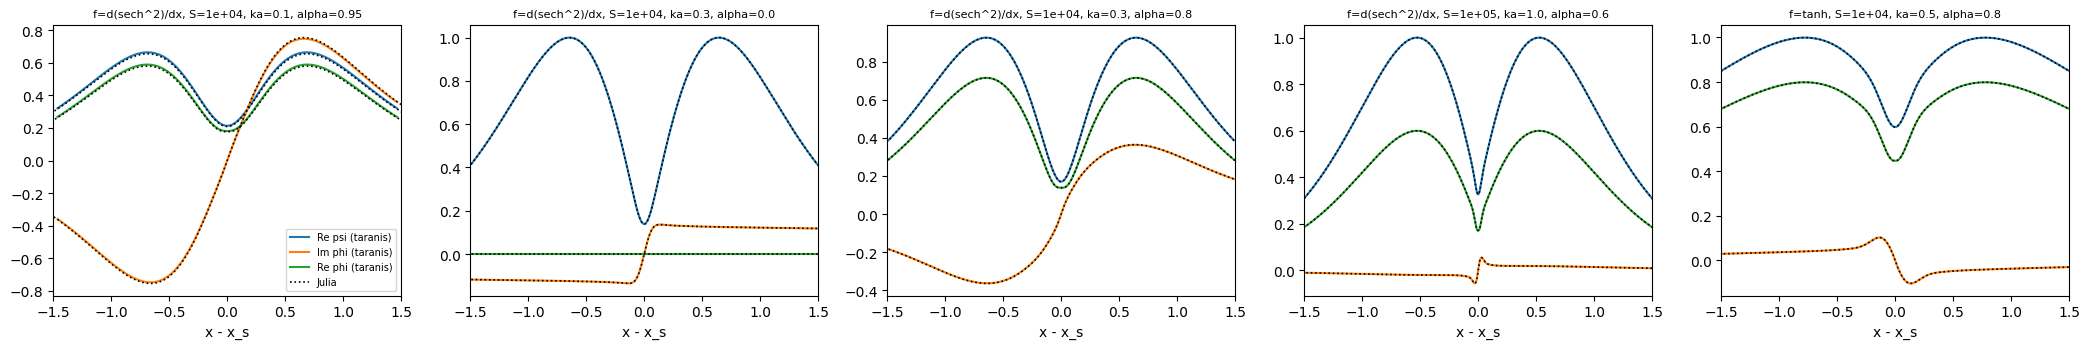

In [3]:
# eigenfunction of the fastest mode against the Julia code's (both normalized as the Julia code
# does: psi real and positive at the sheet, max |[psi; phi]| = 1). alpha -> -alpha maps
# (psi, phi) -> (conj psi, -conj phi): Re psi and Im phi are even in alpha, Im psi and Re phi odd --
# the comparison is complex, and Re phi (plotted, C2) is what pins the sign of alpha
fig, axs = plt.subplots(1, len(REF["eigfn_pids"]), figsize=(4.2*len(REF["eigfn_pids"]), 3.6))
print("  row  (whichf, S, ka, alpha)          max |taranis - Julia| over |x| < 1.4 (psi, phi), normalized units")
for ax, pid in zip(axs, REF["eigfn_pids"]):
    pid = int(pid)
    w, S, ka, al = int(REF["whichf"][pid]), REF["S"][pid], REF["ka"][pid], REF["alpha"][pid]
    case = R.CASES[w]
    res = MAIN[(w, ka, al)][S]
    rec = res["rec"]
    xn, psin, phin = rec["xn"], rec["psin"], rec["phin"]
    xj, pj, fj = REF[f"eigfn_{pid}_x"], REF[f"eigfn_{pid}_psi"], REF[f"eigfn_{pid}_phi"]
    # taranis normalization -> Julia's: phase so psi(0) real > 0 (already), then max|[psi;phi]|=1
    # on the near-sheet window (the maximum sits inside it for every stored point)
    i0 = int(np.argmin(np.abs(xn)))
    ph = np.conj(psin[i0])/abs(psin[i0])
    m = max(np.abs(psin).max(), np.abs(phin).max(), np.abs(rec["psif"]).max(),
            np.abs(rec["phif"]).max())
    pt, ft = psin*ph/m, phin*ph/m
    sel = np.abs(xj) < 1.4                 # inside the stored near-sheet window (+-1.5)
    ptj = np.interp(xj[sel], xn, pt.real) + 1j*np.interp(xj[sel], xn, pt.imag)
    ftj = np.interp(xj[sel], xn, ft.real) + 1j*np.interp(xj[sel], xn, ft.imag)
    print(f"  {pid:3d}  ({w}, {S:.0e}, {ka}, {al})   {np.abs(ptj - pj[sel]).max():.1e}, "
          f"{np.abs(ftj - fj[sel]).max():.1e}")
    ax.plot(xn, pt.real, "C0", lw=1.5, label="Re psi (taranis)")
    ax.plot(xn, ft.imag, "C1", lw=1.5, label="Im phi (taranis)")
    ax.plot(xn, ft.real, "C2", lw=1.5, label="Re phi (taranis)")
    ax.plot(xj, pj.real, "k:", lw=1.2, label="Julia")
    ax.plot(xj, fj.imag, "k:", lw=1.2)
    ax.plot(xj, fj.real, "k:", lw=1.2)
    ax.set_xlim(-1.5, 1.5); ax.set_title(f"f={'tanh' if w == 1 else 'd(sech^2)/dx'}, S={S:.0e}, ka={ka}, alpha={al}", fontsize=8)
    ax.set_xlabel("x - x_s")
axs[0].legend(fontsize=7)
plt.tight_layout()

**Result.** The fastest eigenvalue at $\alpha=\pm0.8$ agrees to $2\times10^{-14}$ (and
`tests/test_tearing_shear.py` checks the whole spectrum). The eigenfunctions of the fastest mode
match the Julia code's stored ones -- same normalization ($\psi$ real at the sheet; with flow
$\phi$ there is real, $\mathrm{Re}\,\phi(0)\approx0.14$-$0.45$, and $\mathrm{Re}\,\phi$ is odd in $\alpha$), **same signs** -- to $7\times10^{-5}$-$1.3\times10^{-3}$ of the maximum over $|x|<1.4$
($1.2\times10^{-2}$ at $S=10^4$, $ka=0.1$, $\alpha=0.95$, where the Julia box matters, §3-4).
With $\alpha$ flipped the same comparison is off by 1.2-1.6 in $\phi$ at the four $\alpha\ne0$ rows. So the two codes solve the same equations with the same sign of $\alpha$, not merely
isospectral ones.

### 2. Box and resolution

**Box.** The flow is localized with the field ($u_y=\alpha f$), so rung 1a's box argument is
unchanged -- the far field of $\phi$ decays like $e^{-k|x|}$ -- but it is re-measured here at
$\alpha=0.6$ and 0.95 (for the tanh pair: the even/odd pair split against the shooting $\Delta'_\pm$).

In [4]:
BOX = R.box_results()
print("sech^2, S = 1e3: converged gamma at Lx = c/k (each converged in nx)")
print("  alpha  ka     c=kLx   Lx     nx(final)   gamma                 rel. to c = 30")
for (ka, al, c), r in sorted(BOX["sech2"].items()):
    if r is None or not r["ok"]:
        continue
    gref = BOX["sech2"][(ka, al, 30.0)]["value"].real
    print(f"  {al:4.2f}  {ka:4.1f}   {c:4.0f}   {max(c/ka, 10):6.1f}   {r['nx'][-1]:6d}    "
          f"{r['value'].real:.12f}   {abs(r['value'].real/gref - 1):.1e}")
print("\ntanh pair, S = 1e3, alpha = 0.8: the even/odd pair at sheet spacing Lx/2 = c/(2k)")
print("  ka    c=kLx   Lx      nx     pair mean            half split   rel.split  "
      "| Delta' shooting: rel. half split")
for (ka, c), r in sorted(BOX["tanhpair"].items()):
    if r is None or not r["ok"]:
        continue
    g, h = R.pair_value(r)
    Lx = max(c/ka, 40.0)
    dp = R.dprime_tanhpair(ka, Lx, 1)/T.dprime_harris_local(ka) - 1
    print(f"  {ka:3.1f}   {c:4.0f}   {Lx:6.1f}  {r['nx'][-1]:6d}  {g:.12f}   {h:.1e}     "
          f"{h/g:.1e}   | {abs(dp):.1e}")

sech^2, S = 1e3: converged gamma at Lx = c/k (each converged in nx)
  alpha  ka     c=kLx   Lx     nx(final)   gamma                 rel. to c = 30
  0.60   0.1     10    100.0     4096    0.024099976911   1.0e-06
  0.60   0.1     15    150.0     4096    0.024099952901   6.8e-09
  0.60   0.1     20    200.0     4096    0.024099952739   4.5e-11
  0.60   0.1     30    300.0     8192    0.024099952738   0.0e+00
  0.95   0.1     10    100.0     4096    0.012256536501   2.6e-05
  0.95   0.1     15    150.0     4096    0.012256225188   1.7e-07
  0.95   0.1     20    200.0     4096    0.012256223090   1.2e-09
  0.95   0.1     30    300.0     8192    0.012256223076   0.0e+00
  0.60   0.3     10     33.3     2048    0.048253371362   2.9e-06
  0.60   0.3     15     50.0     4096    0.048253508638   1.9e-08
  0.60   0.3     20     66.7     4096    0.048253509563   1.3e-10
  0.60   0.3     30    100.0     4096    0.048253509569   0.0e+00
  0.95   0.3     10     33.3     2048    0.021307076694   1.

**Result.** The rung-1a rule $L_x=15/k$ holds with flow: the box error falls by
$\approx e^{-5}$ per $\Delta(kL_x)=5$ (a factor 140-155 per step, i.e. $\propto e^{-kL_x}$) and is
$\le1.7\times10^{-7}$ relative at $kL_x=15$ for $\alpha=0.95$ ($\le1.2\times10^{-7}$ at 0.6) -- it
grows with $\alpha$, most at small $ka$ ($6.8\times10^{-9}\to1.7\times10^{-7}$ at $ka=0.1$; the flow couples the far field of $\phi$ more strongly), and stays
a factor $\ge230$ below the smallest reference error bar ($3.9\times10^{-5}$). For the
tanh pair the half split falls like $e^{-kL_x/2}$ exactly as the shooting $\Delta'_\pm$ predicts
(the eigenvalue split is $\approx0.5$ of the $\Delta'$ split, as $\gamma\propto\Delta'^{\,p}$ with
$p<4/5$), while the **pair mean does not move, to $10^{-8}$ relative ($10^{-10}$ absolute), from $kL_x=20$ to 40** -- the
first-order image shifts $\pm$ cancel in the mean, as the shooting table of §4 shows for $\Delta'$
($10^{-8}$ at $kL_x=20$).

In [5]:
# what the flow does to the grid: final nx of every sech^2 ladder, per alpha
print("final nx of the sech^2 ladders (converged to 1e-7), rows S x ka, columns alpha")
print("   S      ka  " + "".join(f"  alpha={al:<5}" for al in R.ALPHA_REF))
for S in R.S_REF:
    for ka in R.KA_REF:
        row = f"  {S:.0e}  {ka:3.1f} "
        for al in R.ALPHA_REF:
            r = MAIN[(2, ka, al)].get(S)
            row += f"  {r['nx'][-1] if r and r['ok'] else '--':>11}"
        print(row)

final nx of the sech^2 ladders (converged to 1e-7), rows S x ka, columns alpha
   S      ka    alpha=0.0    alpha=0.3    alpha=0.6    alpha=0.8    alpha=0.95 
  1e+03  0.1          4096         4096         4096         4096         4096
  1e+03  0.2          4096         4096         4096         4096         4096
  1e+03  0.3          4096         4096         4096         4096         4096
  1e+03  0.5          2048         2048         2048         2048         2048
  1e+03  0.7          2048         2048         2048         2048         2048
  1e+03  1.0          2048         2048         2048         2048         2048
  1e+04  0.1          8192         8192         8192         8192         4096
  1e+04  0.2          8192         4096         4096         4096         4096
  1e+04  0.3          4096         4096         4096         4096         4096
  1e+04  0.5          4096         4096         2048         2048         2048
  1e+04  0.7          4096         2048         204

**Result: what sets $n_x$.** For sech$^2$ the flow does not make the grid harder -- the layer
widens with $\alpha$ and the ladders end at the same or a smaller $n_x$ ($\le16384$ everywhere,
$S=10^5$, $ka=0.1$). For the tanh pair at $\alpha=0.8$ the scale that matters is not the resistive
layer but an **ideal resonance**: with $\nu=0$ the vorticity equation of the counter-propagating Alfvén wave,
Doppler-shifted by the flow, is singular where $\gamma+ik(\alpha-1)f(x)=0$, i.e. at the complex
distance $d=\gamma/(k(1-\alpha)|f'(0)|)$ from the sheet, and the eigenvector's spectrum decays
like $e^{-k_xd}$. For **tanh** ($|f'|=1$, $\gamma$ 2-8 times smaller than sech$^2$'s) at $\alpha=0.8$,
$d$ drops to 0.1 at $S=10^3$, $ka=0.5$ -- where the pair members are 14 % apart at $dx=0.039$
($L_x=40$), 6 % at $dx=0.029$ and $4\times10^{-6}$ at $dx=0.007$ ($L_x=60$) -- and to 0.064-0.0055
($ka=0.1$-0.7) at $S=10^5$. The $\alpha=0.8$ ladders converge at 13-21 grid points per $d$, i.e.
$n_x\approx20L_x/d$, which at $S=10^5$ is $6\times10^4$-$1.5\times10^5$ even in the reduced box below.
That rule is specific to this case: sech$^2$ has $d$ down to 0.003 ($S=10^5$, $ka=1$, $\alpha=0$;
0.012 at $\alpha=0.8$), and its ladders, like the tanh $\alpha=0$ ones, converge with as few as
0.6-3 points per $d$ -- why the flow makes the tanh pair's resonance so much more demanding is not
established here. All ten $\alpha=0.8$ rows at $S\ge10^4$ run in a smaller box,
$L_x=\max(20/k,40)$, up to $n_x=65536$ (§4); at $S=10^4$, $ka=0.1$ GMRES had also failed at every
shift on the under-resolved $n_x=8192$ rung of the $30/k$ box.

### 3. whichf = 2 ($\Psi_0=\mathrm{sech}^2x$): all 90 points against the Julia code

In [6]:
# THE comparison: every whichf = 2 reference point
print("  S      ka    alpha | gamma taranis       nx    conv.err  resid  | Julia Richardson   "
      "rel.diff  gamma_err  bars | base: bars")
ROWS = []
for S in R.S_REF:
    for ka in R.KA_REF:
        for al in R.ALPHA_REF:
            i = R.ref_index(REF, 2, S, ka, al)
            r = MAIN[(2, ka, al)].get(S)
            if r is None or not r["ok"]:
                print(f"  {S:.0e}  {ka:3.1f}  {al:4.2f}  MISSING"); continue
            g, e = R.point_value("sech2", r)
            gr, gb = REF["gamma_richardson"][i].real, REF["gamma"][i].real
            ge = float(REF["gamma_err"][i])
            rr, rb = abs(g/gr - 1), abs(g/gb - 1)
            ROWS.append((S, ka, al, g, e/g, r["rec"]["rel_residual"], r["nx"][-1], gr, gb, ge, rr, rb))
            print(f"  {S:.0e}  {ka:3.1f}  {al:4.2f}  | {g:.12f}  {r['nx'][-1]:6d}  {e/g:.0e}   "
                  f"{r['rec']['rel_residual']:.0e} | {gr:.12f}  {rr:.1e}   {ge:.1e}   "
                  f"{rr/ge:.3f} | {rb/ge:.3f}")
ROWS = np.array(ROWS)

  S      ka    alpha | gamma taranis       nx    conv.err  resid  | Julia Richardson   rel.diff  gamma_err  bars | base: bars
  1e+03  0.1  0.00  | 0.030207276412    4096  1e-09   4e-12 | 0.030207455812  5.9e-06   2.5e-04   0.024 | 1.024
  1e+03  0.1  0.30  | 0.028787101340    4096  3e-10   4e-12 | 0.028787288839  6.5e-06   2.5e-04   0.026 | 1.026
  1e+03  0.1  0.60  | 0.024099952901    4096  2e-11   4e-12 | 0.024100213309  1.1e-05   4.1e-04   0.026 | 1.026
  1e+03  0.1  0.80  | 0.018419038699    4096  9e-13   6e-12 | 0.018419521164  2.6e-05   6.5e-04   0.040 | 1.040
  1e+03  0.1  0.95  | 0.012256225188    4096  2e-11   2e-14 | 0.012257556030  1.1e-04   5.2e-04   0.210 | 0.790
  1e+03  0.2  0.00  | 0.048496188735    4096  2e-14   6e-12 | 0.048496373986  3.8e-06   2.8e-04   0.014 | 1.014
  1e+03  0.2  0.30  | 0.046096206152    4096  2e-13   6e-12 | 0.046096375556  3.7e-06   2.5e-04   0.015 | 1.015
  1e+03  0.2  0.60  | 0.038159456475    4096  8e-13   7e-12 | 0.038159615954  4.2e-06   3.

per (S, alpha): max over the 6 ka of |gamma_taranis/gamma_Julia,Richardson - 1|, of the same in units of gamma_err, and taranis's own max relative convergence error
   S     alpha   max rel.diff   max bars   min gamma_err   max taranis err   max nx
  1e+03  0.00    5.9e-06       0.024       1.9e-04          1e-09           4096
  1e+03  0.30    6.5e-06       0.026       1.7e-04          3e-10           4096
  1e+03  0.60    1.1e-05       0.026       1.2e-04          2e-11           4096
  1e+03  0.80    2.6e-05       0.040       6.8e-05          2e-12           4096
  1e+03  0.95    1.1e-04       0.210       3.9e-05          2e-11           4096
  1e+04  0.00    4.3e-06       0.010       2.2e-04          3e-10           8192
  1e+04  0.30    3.9e-06       0.010       1.9e-04          4e-08           8192
  1e+04  0.60    3.4e-06       0.008       1.5e-04          6e-09           8192
  1e+04  0.80    2.8e-06       0.007       1.1e-04          1e-11           8192
  1e+04  0.95    6.0e-

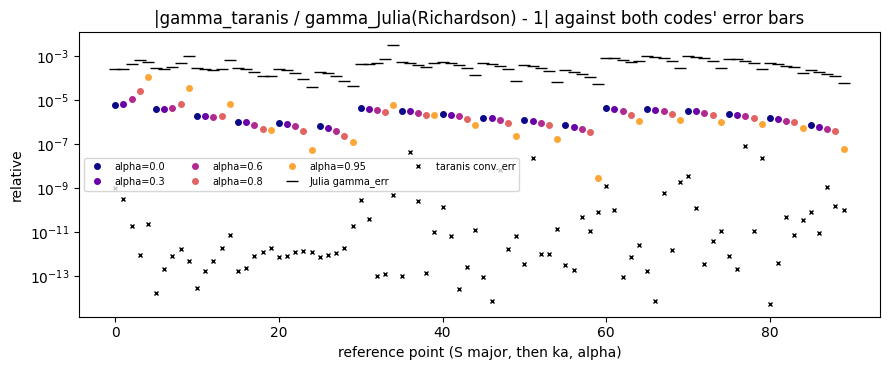

In [7]:
print("per (S, alpha): max over the 6 ka of |gamma_taranis/gamma_Julia,Richardson - 1|, of the same "
      "in units of gamma_err, and taranis's own max relative convergence error")
print("   S     alpha   max rel.diff   max bars   min gamma_err   max taranis err   max nx")
for S in R.S_REF:
    for al in R.ALPHA_REF:
        sel = (ROWS[:, 0] == S) & (ROWS[:, 2] == al)
        rr = ROWS[sel]
        print(f"  {S:.0e}  {al:4.2f}    {rr[:, 10].max():.1e}       {np.max(rr[:, 10]/rr[:, 9]):.3f}"
              f"       {rr[:, 9].min():.1e}          {rr[:, 4].max():.0e}           {int(rr[:, 6].max())}")
ok = np.all(ROWS[:, 10] <= np.maximum(ROWS[:, 9], ROWS[:, 4]))
print(f"\nACCEPTANCE (|rel.diff to Richardson| <= max(gamma_err, taranis err)) at all "
      f"{len(ROWS)} points: {ok};  worst {ROWS[:, 10].max():.1e} relative, "
      f"{np.max(ROWS[:, 10]/ROWS[:, 9]):.3f} of the bar")
print(f"distance to the Julia BASE value in units of gamma_err: {np.min(ROWS[:, 11]/ROWS[:, 9]):.3f}"
      f"-{np.max(ROWS[:, 11]/ROWS[:, 9]):.3f}")

fig, ax = plt.subplots(figsize=(9, 3.8))
for j, al in enumerate(R.ALPHA_REF):
    sel = ROWS[:, 2] == al
    xx = np.arange(len(ROWS))[sel]
    ax.semilogy(xx, ROWS[sel, 10], "o", ms=4, color=plt.cm.plasma(j/5), label=f"alpha={al}")
ax.semilogy(np.arange(len(ROWS)), ROWS[:, 9], "k_", ms=8, label="Julia gamma_err")
ax.semilogy(np.arange(len(ROWS)), ROWS[:, 4] + 1e-16, "kx", ms=3, label="taranis conv. err")
ax.set_xlabel("reference point (S major, then ka, alpha)"); ax.set_ylabel("relative")
ax.set_title("|gamma_taranis / gamma_Julia(Richardson) - 1| against both codes' error bars")
ax.legend(fontsize=7, ncol=4); plt.tight_layout()

**Result: all 90 sech$^2$ points agree.** Against the Julia code's Richardson value, the
relative difference is $2.7\times10^{-9}$-$1.1\times10^{-4}$, i.e. **0.000-0.21 of its error bar**
(median $\approx0.004$); taranis's own convergence errors are $\le8\times10^{-8}$ and the
residuals $\le7\times10^{-11}$. The acceptance (agreement within the larger of the two codes'
errors) holds at every point, with a margin of 4.8 or more everywhere and of 25 or more at all
but the two $S=10^3$, $ka=0.1$, $\alpha\ge0.8$ points. Against the base-grid `gamma` the distance is
1.00-1.04 bars at 83 points -- the base value sits exactly one bar from its own Richardson
value, by construction -- 0.01-0.91 bars at the six $\alpha=0.95$ rows where
`conv_err` rather than the Richardson term sets the bar ($S=10^3$, $ka=0.7,1$; $S=10^4$, $ka=0.5$-1;
$S=10^5$, $ka=1$), and 0.79 at $S=10^3$, $ka=0.1$, $\alpha=0.95$ (0.21 bars from the Richardson value, below).

**The one visible trend, and who is right.** The difference grows toward small $ka$ and large
$\alpha$ at $S=10^3$ ($1.1\times10^{-4}$ at $ka=0.1$, $\alpha=0.95$; $3\times10^{-5}$ at
$ka=0.1$, $\alpha=0.8$ and $ka=0.2$, $\alpha=0.95$) -- where $\phi$ reaches furthest ($e^{-k|x|}$)
and the flow couples it most. taranis's box is converged there (§2: $1.7\times10^{-7}$). The Julia
code's reference grid has $x_{lim}=10$, and its Richardson step extrapolates only $(dx_{min},
\epsilon)$ at that fixed box. §4 re-runs the vendored Julia code unchanged at $x_{lim}=10,20,40$:
its value moves onto taranis's (to $1$-$4\times10^{-7}$ at $x_{lim}=40$). The difference is
the Julia box, and taranis is right to the stated digits.

### 4. whichf = 1 ($f=\tanh x$): the periodic box, and the comparison

A single tanh sheet is not periodic. The plan proposed the Harris-like family
$B_y=\tanh(\sin x/a)/\tanh(1/a)$ (rung 1a §9). Its $\Delta'$ against the isolated sheet's
$\Delta'a=2(1/ka-ka)$, by shooting, at sheet spacing $c/k$:

In [8]:
print("Delta'a of the plan's Harris-like family tanh(sin x/a)/tanh(1/a) (sheet spacing c/k,")
print("a = pi ka/c) against the isolated tanh 2(1/ka - ka): relative error of the even / odd member")
print("   ka    c=k*spacing   even        odd")
for ka, c, e, o in R.harris_dprime_table():
    print(f"  {ka:4.2f}     {c:4.0f}       {e:+.1e}   {o:+.1e}")
print("\n... and of the exact-tanh pair (T.psi0_tanhpair), same spacing c/k = Lx/2:")
for ka in (0.1, 0.2, 0.3, 0.5, 0.7, 1.0):
    dl = T.dprime_harris_local(ka)
    row = f"  {ka:4.2f}  "
    for c in (10.0, 15.0, 20.0):
        dp, dm = (R.dprime_tanhpair(ka, 2*c/ka, s) for s in (1, -1))
        row += (f"   c={c:3.0f}: {dp/dl - 1:+.1e} {dm/dl - 1:+.1e} (mean {0.5*(dp + dm)/dl - 1:+.0e})"
                if dl else f"   c={c:3.0f}: Delta'a = {dp:+.1e} {dm:+.1e}")
    print(row)

Delta'a of the plan's Harris-like family tanh(sin x/a)/tanh(1/a) (sheet spacing c/k,
a = pi ka/c) against the isolated tanh 2(1/ka - ka): relative error of the even / odd member
   ka    c=k*spacing   even        odd
  0.10       10       +2.2e-04   -6.1e-06
  0.10       15       +4.7e-05   +4.6e-05
  0.10       20       +2.6e-05   +2.6e-05
  0.20       10       +8.9e-04   +6.1e-04
  0.20       15       +3.3e-04   +3.3e-04
  0.20       20       +1.9e-04   +1.9e-04
  0.30       10       +2.5e-03   +2.2e-03
  0.30       15       +1.0e-03   +1.0e-03
  0.30       20       +5.9e-04   +5.9e-04
  0.50       10       +1.1e-02   +1.0e-02
  0.50       15       +4.7e-03   +4.7e-03
  0.50       20       +2.6e-03   +2.6e-03
  0.70       10       +3.6e-02   +3.5e-02
  0.70       15       +1.6e-02   +1.6e-02
  0.70       20       +8.7e-03   +8.7e-03

... and of the exact-tanh pair (T.psi0_tanhpair), same spacing c/k = Lx/2:
  0.10     c= 10: +1.1e-04 -1.1e-04 (mean +6e-09)   c= 15: +7.5e-07 -7.5e-07 

In [9]:
HR = R.harris_results()
print("Harris-like family at S = 1e3, c = 15 (a = pi ka/15): gamma a of the even/odd pair against the")
print("exact-tanh pair's and the Julia code's, and the shift predicted from its Delta' error by the")
print("alpha = 0 dispersion relation (the shape error propagated through the inner layer)")
print("  alpha  ka  | Harris-like pair (even, odd)     | tanh pair mean   | Julia Rich.     | "
      "Harris/tanh-1   predicted(alpha=0)")
for (ka, al), r in sorted(HR.items(), key=lambda kv: (kv[0][1], kv[0][0])):
    if r is None or not r["ok"]:
        continue
    a = R.harris_a(ka)
    v = np.sort(np.real(r["rec"]["values"]))[::-1]*a
    rt = MAIN[(1, ka, al)][1e3]
    gt, _ = R.point_value("tanhpair", rt)
    i = R.ref_index(REF, 1, 1e3, ka, al)
    dl = T.dprime_harris_local(ka)
    dp = T.dprime_harris(ka/a, a, +1)*a
    pred = T.gamma_disp(ka, 1e-3, 1.0, dp)/T.gamma_disp(ka, 1e-3, 1.0, dl) - 1
    print(f"  {al:4.2f}  {ka:3.1f} | {v[0]:.8f} {v[1]:.8f}           | {gt:.8f}       | "
          f"{REF['gamma_richardson'][i].real:.8f}    | {v[0]/gt - 1:+.2e}       {pred:+.2e}")

Harris-like family at S = 1e3, c = 15 (a = pi ka/15): gamma a of the even/odd pair against the
exact-tanh pair's and the Julia code's, and the shift predicted from its Delta' error by the
alpha = 0 dispersion relation (the shape error propagated through the inner layer)
  alpha  ka  | Harris-like pair (even, odd)     | tanh pair mean   | Julia Rich.     | Harris/tanh-1   predicted(alpha=0)
  0.00  0.3 | 0.01704899 0.01704897           | 0.01704035       | 0.01704085    | +5.08e-04       +6.08e-04
  0.00  0.5 | 0.01316640 0.01316637           | 0.01312572       | 0.01312574    | +3.10e-03       +3.32e-03
  0.00  0.7 | 0.00842187 0.00842182           | 0.00832075       | 0.00832075    | +1.22e-02       +1.19e-02
  0.80  0.3 | 0.01154377 0.01154376           | 0.01153903       | 0.01153928    | +4.11e-04       +6.08e-04
  0.80  0.5 | 0.01030652 0.01030649           | 0.01028194       | 0.01028195    | +2.39e-03       +3.32e-03
  0.80  0.7 | 0.00790581 0.00790578           | 0.00783708    

**Result: the plan's family is not clean at this precision.** Besides the two-sheet image
coupling (the even/odd split, $\propto e^{-c}$), the Harris-like profile carries a **shape
error common to both members**, $\approx0.04\,(ka)^3$ relative in $\Delta'$ at spacing $15/k$ (i.e. $\propto a^2\,ka$, falling as the
square of the spacing; $\sin x/a\ne x/a$ within
the sheet), which only shrinks with the sheet-to-box ratio: $4.7\times10^{-5}$-$1.6\times10^{-2}$ at
spacing $15/k$, $ka=0.1$-0.7 -- above the reference's error bars ($3\times10^{-5}$-$10^{-3}$)
for $ka\ge0.2$. It propagates into $\gamma$ quantitatively: at $S=10^3$, $\alpha=0$ the
Harris-like eigenvalues sit $5\times10^{-4}$, $3.1\times10^{-3}$, $1.2\times10^{-2}$ above the
clean value at $ka=0.3,0.5,0.7$, against $6\times10^{-4}$, $3.3\times10^{-3}$, $1.2\times10^{-2}$
predicted by passing the $\Delta'$ error through the exact dispersion relation (at $\alpha=0.8$ the flow
lowers the shift by 20-30 %: 0.81, 0.77, 0.72 of the $\alpha=0$ one). A correction is possible but model-dependent (no shear-flow
dispersion relation is exact), so the comparison uses a cleaner box instead.

**The exact-tanh pair** (`T.psi0_tanhpair`: $B_y=-1+\sum_m[\tanh(x-L_x/4-mL_x)-\tanh(x-3L_x/4-mL_x)]$)
is $\tanh$ at each sheet to $e^{-L_x}$, so it has **no shape error**. Its only deviation is the
image coupling, which is **antisymmetric** between the pair members to first order
($\Delta'_\pm=\Delta'_{iso}(1\pm\varepsilon)$, $\varepsilon=7.5\times10^{-7}$-$4.9\times10^{-6}$ at
spacing $15/k$); the pair **mean** is $\Delta'_{iso}$ to $\le10^{-11}$. That is what is compared:
the mean of the two converged pair members, with the error max(change of the mean over the last
ladder rung, half split). $L_x=30/k$ (spacing $15/k$), except the ten $\alpha=0.8$ rows at $S\ge10^4$ where the
Doppler resonance (§2) forces $n_x=65536$: there $L_x=\max(20/k,40)$, at which the mean still carries
$\Delta'$ to $\le4\times10^{-8}$ (and its $O(\varepsilon^2)$ curvature through $\gamma(\Delta')$ is $\lesssim2\times10^{-8}$ in $\gamma$
by the $\alpha=0$ dispersion relation), while the half split quoted as error there is $5\times10^{-6}$-$1.6\times10^{-4}$.

In [10]:
print("whichf = 1 (f = tanh): the exact-tanh pair, pair mean +- (ladder change, half split)")
print("  S      ka   alpha | gamma taranis (mean)  err      nx  kLx | Julia Richardson   rel.diff  "
      "gamma_err  bars | base: bars")
TROWS = []
for S in R.S_REF:
    for ka in R.KA_REF:
        for al in R.ALPHA_F1:
            i = R.ref_index(REF, 1, S, ka, al)
            r = MAIN[(1, ka, al)].get(S)
            if not REF["unstable"][i]:
                d = DENSE[(1, S, ka, al)]
                print(f"  {S:.0e}  {ka:3.1f}  {al:4.2f}  | stable (Julia: no tearing mode); taranis "
                      f"dense max Re = {d['values'][0].real:+.1e} (#Re>0: {int(d['n_pos'])})")
                continue
            if r is None or not r["ok"]:
                print(f"  {S:.0e}  {ka:3.1f}  {al:4.2f}  MISSING"); continue
            g, e = R.point_value("tanhpair", r)
            gr, gb, ge = REF["gamma_richardson"][i].real, REF["gamma"][i].real, float(REF["gamma_err"][i])
            rr, rb = abs(g/gr - 1), abs(g/gb - 1)
            TROWS.append((S, ka, al, g, e/g, r["nx"][-1], gr, gb, ge, rr, rb))
            kL = ka*r["rec"]["Lx"]
            print(f"  {S:.0e}  {ka:3.1f}  {al:4.2f}  | {g:.12f}  {e/g:.0e}  {r['nx'][-1]:6d} {kL:3.0f} | "
                  f"{gr:.12f}  {rr:.1e}   {ge:.1e}  {rr/ge:.3f} | {rb/ge:.3f}")
TROWS = np.array(TROWS)
print(f"\n{len(TROWS)} unstable rows: rel.diff to the Julia Richardson value {TROWS[:, 9].min():.1e}-"
      f"{TROWS[:, 9].max():.1e}, i.e. {np.min(TROWS[:, 9]/TROWS[:, 8]):.3f}-{np.max(TROWS[:, 9]/TROWS[:, 8]):.3f} bars; "
      f"to the base value {np.min(TROWS[:, 10]/TROWS[:, 8]):.2f}-{np.max(TROWS[:, 10]/TROWS[:, 8]):.2f} bars "
      f"({int(np.sum(TROWS[:, 10] > TROWS[:, 8]))} rows outside the base bar)")

whichf = 1 (f = tanh): the exact-tanh pair, pair mean +- (ladder change, half split)
  S      ka   alpha | gamma taranis (mean)  err      nx  kLx | Julia Richardson   rel.diff  gamma_err  bars | base: bars
  1e+03  0.1  0.00  | 0.015554025313  2e-07    8192  30 | 0.015556310150  1.5e-04   4.4e-04  0.331 | 1.331
  1e+03  0.1  0.80  | 0.009078813427  1e-07   16384  30 | 0.009079824570  1.1e-04   2.7e-04  0.417 | 1.417
  1e+03  0.2  0.00  | 0.017860726540  5e-07    8192  30 | 0.017862353876  9.1e-05   3.2e-04  0.286 | 1.285
  1e+03  0.2  0.80  | 0.011196447152  3e-07   16384  30 | 0.011197200782  6.7e-05   2.0e-04  0.343 | 1.197
  1e+03  0.3  0.00  | 0.017040345128  7e-07    4096  30 | 0.017040849152  3.0e-05   1.7e-04  0.176 | 1.176
  1e+03  0.3  0.80  | 0.011539028150  5e-07   16384  30 | 0.011539281446  2.2e-05   6.8e-05  0.325 | 1.259
  1e+03  0.5  0.00  | 0.013125716573  1e-06    4096  30 | 0.013125743443  2.0e-06   7.6e-05  0.027 | 1.027
  1e+03  0.5  0.80  | 0.010281937540  1e-06  

In [11]:
# adjudication: the vendored Julia code re-run (unchanged; the npz is not touched) with its box
# xlim = 10 (the reference), 20, 40, each with a joint (dxmin, eps) ladder 1, 1/2, 1/4 and a 2nd-order
# Richardson step from the last two -- the reference's own Richardson value is xlim = 10 only
ADJ = [(2, 1e3, 0.1, 0.0), (2, 1e3, 0.1, 0.8), (2, 1e3, 0.1, 0.95), (2, 1e3, 0.2, 0.95),
       (2, 1e5, 0.1, 0.0),
       (1, 1e3, 0.1, 0.0), (1, 1e3, 0.1, 0.8), (1, 1e3, 0.2, 0.0), (1, 1e3, 0.3, 0.0),
       (1, 1e4, 0.1, 0.0), (1, 1e4, 0.1, 0.8), (1, 1e5, 0.1, 0.0), (1, 1e5, 0.1, 0.8)]
print("  (whichf, S, ka, alpha)   | Julia 3-level Richardson at xlim = 10, 20, 40        "
      "| taranis           | taranis vs each (relative)             | reference Richardson")
for w, S, ka, al in ADJ:
    tab = R.julia_xlim_table(REF, w, S, ka, al, log=lambda *a: None)
    r = MAIN[(w, ka, al)].get(S)
    if r is None or not r["ok"]:
        print(f"  ({w}, {S:.0e}, {ka}, {al:4.2f})  | taranis value missing"); continue
    g, e = R.point_value(R.CASES[w], r)
    rs = [tab[xl][1] for xl in (10.0, 20.0, 40.0)]
    i = R.ref_index(REF, w, S, ka, al)
    print(f"  ({w}, {S:.0e}, {ka}, {al:4.2f})  | " + "  ".join(f"{v:.10e}" for v in rs)
          + f" | {g:.10e} | " + "  ".join(f"{abs(g/v - 1):.1e}" for v in rs)
          + f" | {abs(g/REF['gamma_richardson'][i].real - 1):.1e}")

  (whichf, S, ka, alpha)   | Julia 3-level Richardson at xlim = 10, 20, 40        | taranis           | taranis vs each (relative)             | reference Richardson
  (2, 1e+03, 0.1, 0.00)  | 3.0207357512e-02  3.0207300596e-02  3.0207280374e-02 | 3.0207276412e-02 | 2.7e-06  8.0e-07  1.3e-07 | 5.9e-06
  (2, 1e+03, 0.1, 0.80)  | 1.8419280968e-02  1.8419105496e-02  1.8419042974e-02 | 1.8419038699e-02 | 1.3e-05  3.6e-06  2.3e-07 | 2.6e-05
  (2, 1e+03, 0.1, 0.95)  | 1.2256893286e-02  1.2256401982e-02  1.2256226907e-02 | 1.2256225188e-02 | 5.5e-05  1.4e-05  1.4e-07 | 1.1e-04
  (2, 1e+03, 0.2, 0.95)  | 1.8543227698e-02  1.8542942076e-02  1.8542931075e-02 | 1.8542928583e-02 | 1.6e-05  7.3e-07  1.3e-07 | 3.4e-05
  (2, 1e+05, 0.1, 0.00)  | 7.1556372587e-03  7.1556335093e-03  7.1556321630e-03 | 7.1556296787e-03 | 1.1e-06  5.4e-07  3.5e-07 | 4.0e-06
  (1, 1e+03, 0.1, 0.00)  | 1.5555164878e-02  1.5554332959e-02  1.5554037376e-02 | 1.5554025313e-02 | 7.3e-05  2.0e-05  7.8e-07 | 1.5e-04
  (1, 1e+03,

**Result.** All unstable tanh rows agree with the Julia Richardson value to within its bar,
at 0.00-0.42 bars (the table's summary line). Unlike sech$^2$, the difference is systematically
**0.18-0.42 bars at $ka\le0.3$** and falls to 0.001-0.044 at $ka\ge0.5$; 25 of the 30 rows are 1.003-1.42
bars from the base value, i.e. just outside the base value's own bar. That is the Julia box again, and here it is large: a tanh sheet's outer $\psi$ is
$\propto e^{-k|x|}$ at full amplitude out to $x_{lim}$ (no $\mathrm{sech}^2$ decay), and the Robin
row imitates $e^{-K|x|}$ only to first order in $K\,dx$ on the coarse outer grid. The re-run
Julia code converges onto taranis as $x_{lim}$ grows: from $1.5\times10^{-5}$-$1.6\times10^{-4}$ at
$x_{lim}=10$ to **$4\times10^{-8}$-$1.7\times10^{-6}$ at $x_{lim}=40$**, for all six
$S$-$\alpha$ combinations at $ka=0.1$ and at $ka=0.2$, 0.3 ($S=10^3$, $\alpha=0$). The same is true of the sech$^2$
outliers ($1.3$-$3.5\times10^{-7}$ at $x_{lim}=40$). **Where the two codes differ, the Julia
reference's outer box is what is wrong** -- by 0.2-0.4 of its own error bar, so the reference's bar
is honest (its `xlim_double` variant sees the effect and enters `conv_err`), but its Richardson
value is not the continuum value to the digits the bar suggests.

**Caveat: where taranis's own error is the larger one.** At $\alpha=0.8$, five rows quote an error above the Julia bar. **One is a grid error:** $S=10^5$, $ka=0.7$, whose ladder ends at $n_x=65536$ with the mean still moving ($2.6\times10^{-4}$ over the last rung; §2's rule $n_x\approx20L_x/d$ asks for $\sim1.5\times10^5$). There the acceptance holds only because the plan takes the LARGER of the two codes' errors. The $0.007$-bar agreement is consistent with the ladder's own trend -- the mean's increments fell 44-fold over the last rung ($8.8\times10^{-6}\to2.0\times10^{-7}$ absolute), which, if that rate holds, leaves $\sim6\times10^{-6}$ relative -- but that is an extrapolation; no converged ladder demonstrates it. **The other four quote the half split:** $S=10^4$ and $10^5$, $ka=0.3$, 0.5, in the reduced box $L_x=\max(20/k,40)$, $9.4\times10^{-5}$-$1.6\times10^{-4}$. At $S=10^4$ the ladders are converged (the mean's last change $\le7\times10^{-10}$) and the split has stopped moving, so the bound is the box's; the split is antisymmetric to first order and the mean is box-independent to $10^{-8}$ (§2), so it is conservative. At $S=10^5$ only the mean is converged (last change $1.2\times10^{-7}$ and $7\times10^{-7}$; the ladders are not, by the $10^{-7}$ criterion) and the split is still falling with $n_x$ ($ka=0.5$: $4.1\to1.55\times10^{-7}$ absolute over the last rung), so there the bound is part grid, part box. The $S=10^4$ rows used to stop at the $n_x=16384$ cap in the $L_x=30/k$ box, under-resolved (review 2026-09-29). They were rerun in the reduced box to $n_x=65536$, where the mean converges to $\le2.2\times10^{-8}$; the Julia comparison moved by at most $0.094$ bars ($ka=0.7$: 0.097 to 0.003; $ka=0.2$-0.5 by $\le0.004$; the $ka=0.1$ ladder had failed in the $30/k$ box).

### 5. Which mode is the fastest: dense spectra, and the Julia `:SR` selection

The Julia code's protocol (`eigenmode`) is shift-invert Arnoldi about a theory guess selecting
`:SR` of $1/(\gamma-\sigma)$ -- the eigenvalue just *below* the guess, not provably the fastest.
The reference npz already records, per grid, whether that `:SR` value equals the maximum-Re
eigenvalue of the Julia code's own dense spectrum (`si_agrees`, `fast_matches_dense`). Here the
check is independent: the **whole** taranis ky-block spectrum on each point's seed grid.

In [12]:
# fastest-mode certification: the WHOLE ky-block spectrum on the seed grid of every point
print("  f   S      ka   alpha  nx    #Re>0 | fastest (dense)             | converged ladder    "
      "rel.diff | Julia :SR (base)    |fast-mode Julia==:SR")
CERT = []
for (w, S, ka, al), d in sorted(DENSE.items()):
    i = R.ref_index(REF, w, S, ka, al)
    lam = complex(d["values"][0])
    r = MAIN.get((w, ka, al), {}).get(S)
    if REF["unstable"][i] and r is not None and r["ok"]:
        g, _ = R.point_value(R.CASES[w], r)
        rel = abs(lam.real/g - 1)
        real = abs(lam.imag) <= 1e-8*abs(lam)
    else:
        g, rel, real = np.nan, np.nan, False
    CERT.append((w, S, ka, al, int(d["nx"]), int(d["n_pos"]), lam, g, rel, real,
                 bool(np.all(REF["si_agrees"][i])), REF["gamma_si"][i, 0]))
    print(f"  {w}  {S:.0e}  {ka:3.1f}  {al:4.2f}  {int(d['nx']):5d}  {int(d['n_pos']):3d}  | "
          f"{lam.real:+.8e}{lam.imag:+.1e}i | {g:.10e}  {rel:.1e} | "
          f"{REF['gamma_si'][i, 0].real:+.8e} | {bool(np.all(REF['si_agrees'][i]))}")

  f   S      ka   alpha  nx    #Re>0 | fastest (dense)             | converged ladder    rel.diff | Julia :SR (base)    |fast-mode Julia==:SR
  1  1e+03  0.1  0.00   2048    2  | +1.55564532e-02+2.4e-16i | 1.5554025313e-02  1.6e-04 | +1.55632200e-02 | True
  1  1e+03  0.1  0.80   2048    2  | +9.72083914e-03+1.2e-17i | 9.0788134266e-03  7.1e-02 | +9.08224898e-03 | True
  1  1e+03  0.2  0.00   2048    2  | +1.78607330e-02-2.8e-17i | 1.7860726540e-02  3.6e-07 | +1.78680540e-02 | True
  1  1e+03  0.2  0.80   2048    2  | +1.15525893e-02+1.9e-15i | 1.1196447152e-02  3.2e-02 | +1.11990808e-02 | True
  1  1e+03  0.3  0.00   2048    2  | +1.70403575e-02-3.4e-16i | 1.7040345128e-02  7.3e-07 | +1.70437084e-02 | True
  1  1e+03  0.3  0.80   2048    2  | +1.18134010e-02+5.5e-15i | 1.1539028150e-02  2.4e-02 | +1.15400104e-02 | True
  1  1e+03  0.5  0.00   2048    2  | +1.31257358e-02+4.0e-16i | 1.3125716573e-02  1.5e-06 | +1.31267358e-02 | True
  1  1e+03  0.5  0.80   2048    2  | +1.05517888e-02-

**Result.** At $S=10^3$ -- where the sech$^2$ seed grid is itself converged -- the fastest
eigenvalue of the **whole** block spectrum equals the converged tearing eigenvalue to $\le10^{-9}$ at all 30
sech$^2$ points and is the only growing mode, except at $ka=0.1$, $\alpha\le0.6$, where three
eigenvalues grow: the tearing mode and rung 1a's overstable twisting pair (the "surprise" mode,
$\mathrm{Re}\,\lambda\approx7\times10^{-4}$, 40 times slower), exactly the Julia code's own dense
count (`n_pos_dense` = 3 at the same three points, 1 at $\alpha=0.8, 0.95$ -- the flow stabilizes
the pair). At $S=10^4$-$10^5$ the seed grid under-resolves the layer at small $\alpha$ (the dense top is up to 6 %
off the converged value, largest at $\alpha=0$ and small $ka$; at $\alpha=0.95$ it is still $\le10^{-4}$), but every spectrum still has **exactly one**
growing eigenvalue, real, on the tearing branch -- no competitor appears at any resolution. For
tanh every unstable row has exactly the two pair members growing (at $\alpha=0.8$ the seed grid is
under-resolved already at $S=10^3$ -- 2-7 % off, the Doppler resonance of §2 -- but shows no third
growing mode at any $S$), and **no eigenvalue grows at $ka=1$** (all six $S,\alpha$; max Re at round-off), which is the Julia code's `unstable=False`.

**The `:SR` question.** The npz shows the Julia protocol's `:SR`-below-guess eigenvalue equal to
its dense maximum-Re eigenvalue on every grid of every unstable row (`si_agrees` all True);
taranis's independent full spectra agree that this eigenvalue is the fastest mode. **`:SR` never
missed the fastest mode in this window.** (Its failure mode -- a guess below the fastest mode --
is shown by the npz's `audit_lowguess` row, not here.)

### 6. Science inside the window: $\gamma(\alpha)$, $k_{max}(\alpha)$, and the inner layer

**Growth rate against $k$** (the paper's fig. 2 trend), taranis lines, Julia `+`. Extra $ka$
(0.15, 0.4, 0.6, 0.85) locate the peak.

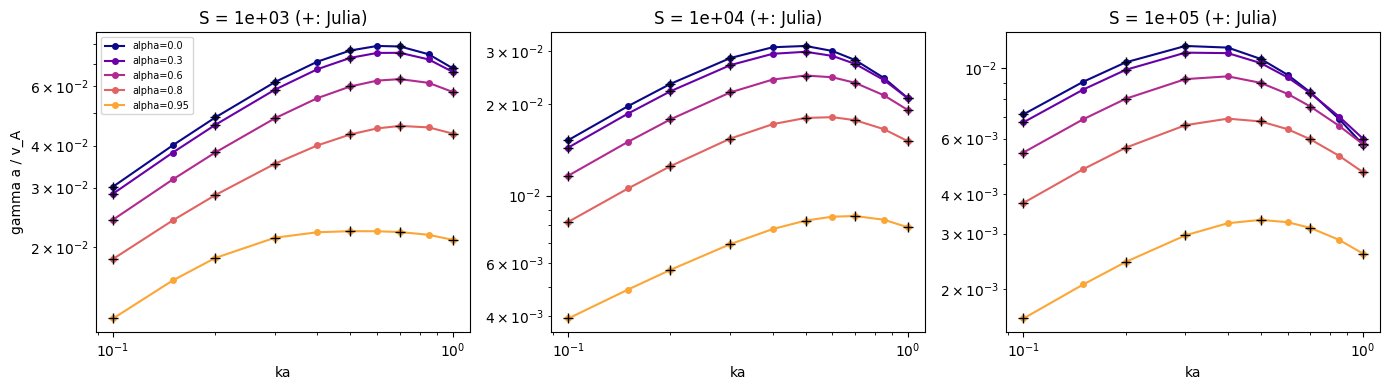

In [13]:
EXTRA = R.extra_results()
def branch(S, al):
    # (ka, gamma) over the reference ka and the extra ka, sech^2
    pts = [(ka, MAIN[(2, ka, al)][S]) for ka in R.KA_REF] + \
          [(ka, EXTRA[(ka, al)][S]) for ka in R.KA_EXTRA if (ka, al) in EXTRA and S in EXTRA[(ka, al)]]
    pts = sorted((ka, r["value"].real) for ka, r in pts if r is not None and r["ok"])
    return np.array(pts)

fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, S in zip(axs, R.S_REF):
    for j, al in enumerate(R.ALPHA_REF):
        b = branch(S, al)
        ax.loglog(b[:, 0], b[:, 1], "o-", ms=4, color=plt.cm.plasma(j/5), label=f"alpha={al}")
        sel = (REF["whichf"] == 2) & (REF["S"] == S) & (REF["alpha"] == al)
        ax.loglog(REF["ka"][sel], REF["gamma_richardson"][sel].real, "k+", ms=7)
    ax.set_title(f"S = {S:.0e} (+: Julia)"); ax.set_xlabel("ka")
axs[0].set_ylabel("gamma a / v_A"); axs[0].legend(fontsize=7)
plt.tight_layout()

peak of gamma(k) per (S, alpha): quadratic in ln k through the three largest of the 10 ka, spread against a cubic through the five around the peak
   S     alpha    k_max            gamma_max          k_max/k_max(0)  (1-a^2)^(-1/7) | gamma_max/gamma_max(0)  (1-a^2)^(4/7)
  1e+03  0.00   0.6353 +- 3e-03   7.924240e-02 +- 2e-05    1.000           1.000        |   1.000                1.000
  1e+03  0.30   0.6499 +- 2e-03   7.574226e-02 +- 4e-05    1.023           1.014        |   0.956                0.948
  1e+03  0.60   0.6872 +- 3e-03   6.306347e-02 +- 2e-05    1.082           1.066        |   0.796                0.775
  1e+03  0.80   0.7295 +- 5e-03   4.580099e-02 +- 1e-05    1.148           1.157        |   0.578                0.558
  1e+03  0.95   0.5374 +- 2e-02   2.228760e-02 +- 5e-06    0.846           1.395        |   0.281                0.264
  1e+04  0.00   0.4633 +- 7e-04   3.131327e-02 +- 4e-05    1.000           1.000        |   1.000                1.000
  1e+04  0.30 

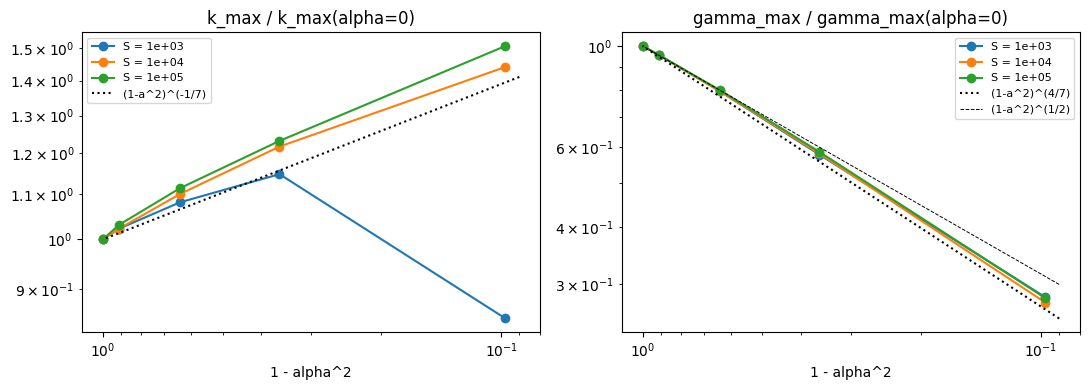

In [14]:
print("peak of gamma(k) per (S, alpha): quadratic in ln k through the three largest of the 10 ka, "
      "spread against a cubic through the five around the peak")
print("   S     alpha    k_max            gamma_max          k_max/k_max(0)  (1-a^2)^(-1/7) | "
      "gamma_max/gamma_max(0)  (1-a^2)^(4/7)")
PEAK = {}
for S in R.S_REF:
    for al in R.ALPHA_REF:
        b = branch(S, al)
        i = int(np.argmax(b[:, 1])); lo = max(0, min(i - 2, len(b) - 5))
        bb = b[lo:lo + 5]
        PEAK[(S, al)] = T.peak_fit(bb[:, 0], bb[:, 1])
    k0, g0 = PEAK[(S, 0.0)][:2]
    for al in R.ALPHA_REF:
        km, gm, dk, dg = PEAK[(S, al)]
        print(f"  {S:.0e}  {al:4.2f}   {km:.4f} +- {dk:.0e}   {gm:.6e} +- {dg:.0e}   {km/k0:6.3f}"
              f"          {(1 - al**2)**(-1/7):6.3f}        |  {gm/g0:6.3f}               "
              f"{(1 - al**2)**(4/7):6.3f}")

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for j, S in enumerate(R.S_REF):
    a_ = np.array(R.ALPHA_REF); om = 1 - a_**2
    km = np.array([PEAK[(S, al)][0] for al in R.ALPHA_REF]); gm = np.array([PEAK[(S, al)][1] for al in R.ALPHA_REF])
    axs[0].loglog(om, km/km[0], "o-", color=f"C{j}", label=f"S = {S:.0e}")
    axs[1].loglog(om, gm/gm[0], "o-", color=f"C{j}", label=f"S = {S:.0e}")
oo = np.geomspace(0.09, 1, 50)
axs[0].loglog(oo, oo**(-1/7), "k:", label="(1-a^2)^(-1/7)")
axs[1].loglog(oo, oo**(4/7), "k:", label="(1-a^2)^(4/7)")
axs[1].loglog(oo, oo**(1/2), "k--", lw=0.7, label="(1-a^2)^(1/2)")
for ax, t in zip(axs, ("k_max / k_max(alpha=0)", "gamma_max / gamma_max(alpha=0)")):
    ax.set_xlabel("1 - alpha^2"); ax.set_title(t); ax.legend(fontsize=8); ax.invert_xaxis()
plt.tight_layout()

**Result: the paper's trends hold in the window, with one finite-$S$ exception.** (i) $\gamma$
falls monotonically with $\alpha$ at every $(S,ka)$ except $ka=1$, $S\ge10^4$, where weak shear
*raises* it slightly -- by $4\times10^{-4}$ ($S=10^4$) and 4.5 % ($S=10^5$) at $\alpha=0.3$, still
+0.4 % at $\alpha=0.6$, $S=10^5$ -- identically in both codes (the large-$ka$, constant-$\psi$ side of
the window; not investigated further here). At the peak of
$\gamma(k)$ the suppression is clean: $\gamma_{max}(\alpha)/\gamma_{max}(0)$ =
0.955, 0.80, 0.58, 0.28 at $\alpha$ = 0.3, 0.6, 0.8, 0.95 -- the same at all three $S$ to $\pm0.01$,
a few % above the asymptotic $(1-\alpha^2)^{4/7}$ = 0.948, 0.775, 0.558, 0.264 (the paper's
maximum-growth exponent). (ii) $k_{max}$ **increases with $\alpha$** at $S=10^4$ and $10^5$ -- by
1.44 and 1.51 at $\alpha=0.95$, a little faster than the asymptotic $(1-\alpha^2)^{-1/7}$ = 1.40 --
and at $S=10^3$ up to $\alpha=0.8$ (1.15). **At $S=10^3$, $\alpha=0.95$ it falls back** to
$ka\approx0.54$ (0.85 of $\alpha=0$): there $\gamma(k)$ is flat to 0.1 % over $ka$ = 0.5-0.6 and
both codes agree on it (Julia: 0.022280 and 0.022142 at 0.5 and 0.7; taranis 0.022277, 0.022142).
At such low $S$ the shear-modified layer is no longer thin compared with $1/k$, so the $k_{max}$
scaling is a trend in $S$ that sets in by $S=10^4$, not a property of every point. The $k_{max}$
fit error is $\le8\times10^{-3}$ ($2\times10^{-2}$ at the flat $S=10^3$, $\alpha=0.95$ curve).

**Inner-layer width.** The paper's definition (§7): the full width where $\mathrm{Re}\,\psi''\ge
\max/4$, $\psi$ phase-normalized real at the sheet. The Julia code's `din_meas` is the same
measurement on its base grid; paper eq. (5.15),
$\delta_{in}\sim(\alpha/(1-\alpha^2))^{1/3}(ka)^{-1/3}S^{-1/3}$, is an asymptotic scaling with no
order-unity constant.

In [15]:
print("inner-layer width (paper §7: full width where Re psi'' >= max/4), taranis eigenfunction vs "
      "the Julia code's (base grid) and paper eq. 5.15")
print("  S      ka   alpha | width taranis  Julia(base)  ratio | delta_in(5.15)  width/5.15")
W = []
for S in R.S_REF:
    for ka in R.KA_REF:
        for al in R.ALPHA_REF:
            i = R.ref_index(REF, 2, S, ka, al)
            r = MAIN[(2, ka, al)][S]
            w = float(r["rec"]["width"]); wj = float(REF["din_meas"][i, 0]); d5 = float(REF["delta_in_515"][i])
            W.append((S, ka, al, w, wj, d5))
            print(f"  {S:.0e}  {ka:3.1f}  {al:4.2f} |  {w:.5f}       {wj:.5f}     {w/wj:.4f} | "
                  f"{d5:.5f}         {w/d5 if np.isfinite(d5) else np.nan:.3f}")
W = np.array(W)

inner-layer width (paper §7: full width where Re psi'' >= max/4), taranis eigenfunction vs the Julia code's (base grid) and paper eq. 5.15
  S      ka   alpha | width taranis  Julia(base)  ratio | delta_in(5.15)  width/5.15
  1e+03  0.1  0.00 |  0.39330       0.38114     1.0319 | inf         nan
  1e+03  0.1  0.30 |  0.39828       0.38614     1.0314 | 0.14883         2.676
  1e+03  0.1  0.60 |  0.41520       0.40513     1.0248 | 0.21086         1.969
  1e+03  0.1  0.80 |  0.43810       0.43084     1.0168 | 0.28114         1.558
  1e+03  0.1  0.95 |  0.46572       0.44807     1.0394 | 0.46016         1.012
  1e+03  0.2  0.00 |  0.34070       0.33141     1.0280 | inf         nan
  1e+03  0.2  0.30 |  0.34642       0.33970     1.0198 | 0.11813         2.933
  1e+03  0.2  0.60 |  0.36629       0.35819     1.0226 | 0.16736         2.189
  1e+03  0.2  0.80 |  0.39600       0.38605     1.0258 | 0.22314         1.775
  1e+03  0.2  0.95 |  0.43456       0.42997     1.0107 | 0.36523         1.19

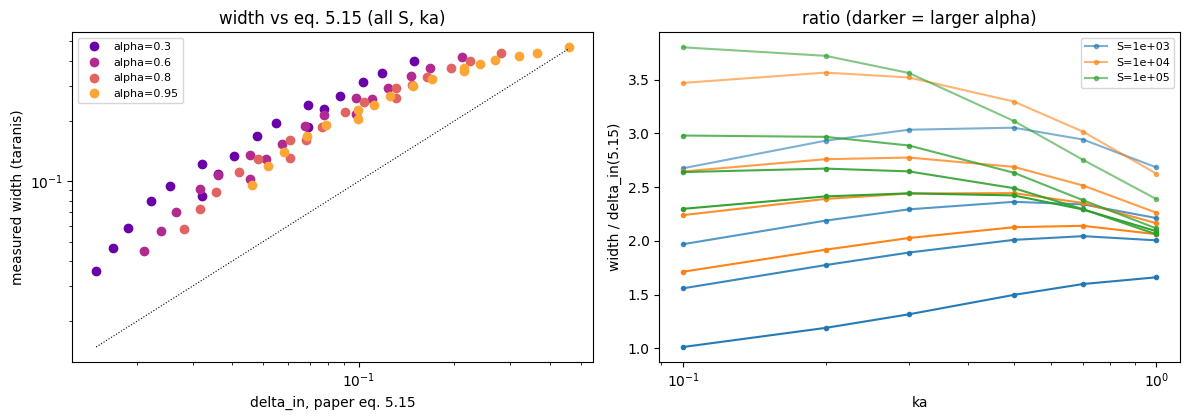

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.3))
for j, al in enumerate(R.ALPHA_REF[1:]):
    sel = W[:, 2] == al
    axs[0].loglog(W[sel, 5], W[sel, 3], "o", color=plt.cm.plasma((j + 1)/5), label=f"alpha={al}")
xx = np.geomspace(W[W[:, 2] > 0, 5].min(), W[W[:, 2] > 0, 5].max(), 10)
axs[0].loglog(xx, xx, "k:", lw=0.8); axs[0].set_xlabel("delta_in, paper eq. 5.15")
axs[0].set_ylabel("measured width (taranis)"); axs[0].legend(fontsize=8)
axs[0].set_title("width vs eq. 5.15 (all S, ka)")
for j, S in enumerate(R.S_REF):
    for al in R.ALPHA_REF[1:]:
        sel = (W[:, 0] == S) & (W[:, 2] == al)
        axs[1].semilogx(W[sel, 1], W[sel, 3]/W[sel, 5], "o-", ms=3, color=f"C{j}",
                        alpha=0.4 + 0.6*al, label=f"S={S:.0e}" if al == 0.3 else None)
axs[1].set_xlabel("ka"); axs[1].set_ylabel("width / delta_in(5.15)")
axs[1].set_title("ratio (darker = larger alpha)"); axs[1].legend(fontsize=8)
plt.tight_layout()

**Result.** taranis's width and the Julia code's `din_meas` agree to **+0.1 to +3.9 %** at all 90
points, taranis always the wider. The sign and size are those of the Julia measurement's
edge rule: `findfirst`/`findlast` on grid points, with no interpolation, under-counts by up to one
local spacing $dx_{min}+\epsilon|x|\approx0.008$ per side at $w\approx0.4$ (taranis interpolates
the $\max/4$ crossing on a grid 10-100 times finer). Against paper eq. (5.15) the measured width is
1.0-3.8 $\delta_{in}$: the ratio is not constant across the window -- 5.15 is an asymptotic
scaling for the shear-modified layer ($\delta_{in}\gg\delta_\eta$), and at $S\le10^5$ the
resistive width still competes. At fixed $S$ and $ka$ the width grows with $\alpha$ more slowly
than $(\alpha/(1-\alpha^2))^{1/3}$ at small $ka$ (ratio 3.8 $\to$ 2.3 from $\alpha=0.3$ to 0.95 at
$S=10^5$, $ka=0.1$). It tracks it within 3 % for $\alpha\ge0.6$ at $ka=1$ (ratio 2.12, 2.06, 2.09 at
$S=10^5$). The flow's effect on the layer is unmistakable: at $ka=0.1$ the width grows by
1.9$\times$ from $\alpha=0$ to 0.95 at $S=10^5$.

### 7. Summary

* **Same equations, same sign.** The linearized ky block about $(\alpha\Psi_0,\Psi_0)$ is term for term
  the Julia pencil; the spectrum is even in $\alpha$ ($2\times10^{-14}$), and the eigenfunctions
  match the Julia code's stored ones, signs included, to $\le1.3\times10^{-3}$ of their maximum ($1.2\times10^{-2}$ at the one row where the Julia box matters).
* **sech$^2$, 90/90 points agree:** $|\gamma_{taranis}/\gamma_{Julia,Rich}-1|$ =
  $2.7\times10^{-9}$-$1.1\times10^{-4}$, i.e. 0.000-0.21 of the reference's error bar (typically
  $10^{-6}$ and 0.003-0.03 bars), with taranis converged to $\le10^{-7}$ in $n_x$ and
  $\le2\times10^{-7}$ in $L_x$ and residuals $\le10^{-10}$. Against the base-grid `gamma` it is ~1
  bar, by construction of that bar.
* **tanh, 30/30 unstable points agree** (0.00-0.42 bars; one row, $\alpha=0.8$, $S=10^5$, $ka=0.7$, is not ladder-converged at the $n_x=65536$
  cap -- last change $2.6\times10^{-4}$, above the Julia bar, though its increments shrink 44-fold per rung -- and four more quote a half-split bound above it, set by the box at $S=10^4$ and part grid at $S=10^5$ -- §4), and the 6 stable ($ka=1$) points have no
  growing eigenvalue. This required replacing the plan's Harris-like box, whose $O(a^2)$ shape error
  in $\Delta'$ (up to $1.6\times10^{-2}$) is visible in $\gamma$, by an exact-tanh sheet pair
  whose pair-mean $\Delta'$ is exact to $10^{-11}$ at spacing $15/k$ ($\le4\times10^{-8}$ in the reduced box of the ten $\alpha=0.8$, $S\ge10^4$ rows).
* **Disagreements and who is wrong.** The residual differences grow toward small $ka$ (to
  $1.1\times10^{-4}$ for sech$^2$, $3.3\times10^{-4}$ for tanh). Re-running the vendored Julia code
  unchanged with a larger outer box ($x_{lim}$ = 10, 20, 40, each Richardson-extrapolated) moves it
  onto taranis, to $4\times10^{-8}$-$1.7\times10^{-6}$ at $x_{lim}=40$ at all 13 points checked. The
  reference's $x_{lim}=10$ box (with a first-order Robin row) is the error, inside its stated bar.
  The npz was not regenerated.
* **Fastest mode.** Whole-spectrum dense solves at every point: exactly one growing real mode
  everywhere (tearing), except the known overstable twisting pair at $S=10^3$, $ka=0.1$,
  $\alpha\le0.6$ (flow-stabilized by $\alpha=0.8$; the Julia code's dense count agrees), and the
  tanh pair. The Julia `:SR`-below-guess selection **never missed the fastest mode** in the window.
* **Science.** $\gamma_{max}(\alpha)/\gamma_{max}(0)$ = 0.955, 0.80, 0.58, 0.28 ($\alpha$ = 0.3-0.95),
  $S$-independent to 0.01 and a few % above $(1-\alpha^2)^{4/7}$; $k_{max}$ grows with $\alpha$
  (by 1.44-1.51 at $\alpha=0.95$, $S\ge10^4$), except at $S=10^3$, $\alpha=0.95$, where the flat
  $\gamma(k)$ peaks back at 0.54. Weak shear slightly *raises* $\gamma$ at $ka=1$, $S\ge10^4$ (both
  codes). The layer width agrees with the Julia code's to +0.1-3.9 %, explained by its unrounded
  grid-point edges. Against eq. (5.15) it is 1.0-3.8 $\delta_{in}$, not yet asymptotic at $S\le10^5$.

**Measured method limits.**
* For the tanh pair at $\alpha=0.8$ the cost is set by an **ideal Doppler-shifted Alfvén resonance**, $\gamma+ik(\alpha-1)f=0$ at complex
  distance $d=\gamma/(k(1-\alpha)|f'|)$, not by the resistive layer: its ladders converge at $n_x\approx20L_x/d$, which forces $n_x=65536$ at
  $S\ge10^4$ in a reduced box $L_x=\max(20/k,40)$. sech$^2$ ($n_x\le16384$) and tanh at $\alpha=0$ converge with as few as
  0.6-3 points per $d$; why the flow makes the tanh resonance so much more demanding is open. Extrapolating, $\alpha\to1$ or $S\gtrsim10^6$ on a uniform
  periodic grid is out of laptop reach; that is the stretched-grid eigencode's regime.
* The tanh-pair members converge much more slowly than their mean: across the cached ladders the mean's error is
  7-600 times smaller than the members' separation (0.1 % apart with the mean right to $2\times10^{-6}$), but members
  5 % or more apart always came with the mean off by $\ge2\times10^{-3}$. Compare converged means, never a single member.
* Dense certification is decisive only where the seed grid is converged ($S=10^3$). At $S\ge10^4$ it
  certifies "no competitor at any resolution tried", not the converged ordering.
* GMRES with the band-LU preconditioner fails (and the ladder retries at a moved shift) when $n_x$
  is far below the resonance scale. One ladder (tanh, $S=10^4$, $ka=0.1$, $\alpha=0.8$, $L_x=30/k$)
  failed at every shift and was rerun in the smaller box.

In [17]:
# data-generation cost: the solve times as recorded (the machine was shared; indicative only)
import glob
paths = glob.glob(os.path.join(R.DATA_ROOT, "solves", "*.npz"))
recs = [np.load(p) for p in paths]
secs = np.array([float(r["seconds"]) for r in recs]); nxs = np.array([int(r["nx"]) for r in recs])
size = sum(os.path.getsize(p) for p in paths)
print(f"{len(recs)} cached eigen-solves, {secs.sum()/3600:.2f} h of solve time in total, "
      f"{size/2**20:.1f} MiB on disk; largest nx = {nxs.max()}, slowest solve {secs.max():.0f} s")

780 cached eigen-solves, 16.98 h of solve time in total, 73.0 MiB on disk; largest nx = 65536, slowest solve 7367 s
